# Ejercicio 5

El dataset `wine_quality.xlsx` contiene información acerca del puntaje que un panel de enólogos asignó a una serie de 76 vinos de tipo Pinot Noir. Las cualidades evaluadas incluyeron algunas propiedades organolépticas como claridad (clarity), aroma (aroma), cuerpo (body) y sabor (flavor) y una valoración de la calidad general del vino (quality). Adicionalmente, se recabó información sobre el grado de envejecimiento (aging) de cada uno de los productos evaluados, la cual se encuentra en el dataset `wine_aging.csv`.

1. Importe ambos datasets y realice cualquier tarea de limpieza y adecuación de los mismos que considere necesaria para su posterior análisis.

2. ¿Cuál es el tipo de vino (crianza/reserva/gran reserva) que presenta la mayor mediana para el sabor?

3. Construya la matriz de covariancia de las distintas variables cuantitativas que componen el dataset y comente qué tipo de información le aporta acerca de la relación entre los distintos pares de variables cuantitativas del dataset.

4. Construya la matriz de correlación de las distintas variables cuantitativas que componen el dataset. En base al mismo, identifique la/s variable/s que se encuentran más fuertemente correlacionadas e informe e interprete la medida de asociación lineal correspondiente

5. Elija el par de variables que identificó en el ítem anterior como aquellas que se encuentran más fuertemente correlacionadas linealmente y realice un gráfico que le permita visualizar la relación general que existe entre las mismas.

In [134]:
import pandas as pd
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt

## Item 1

Importe ambos datasets y realice cualquier tarea de limpieza y adecuación de los mismos que considere necesaria para su posterior análisis.

In [135]:
pd_wine_qiality = pd.read_excel('../datasets/wine_quality.xlsx', engine='openpyxl', header=2)
pd_wine_qiality.head()

,id,clarity,aroma,body,flavor,quality
0,1,1.0,3.3,2.8,3.1,9;8
1,2,1.0,4.4,4.9,3.5,12;6
2,3,1.0,3.9,5.3,4.8,11;9
3,4,1.0,3.9,2.6,3.1,11;1
4,4,1.0,3.9,2.6,3.1,11;1


In [136]:
pd_wine_qiality.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       77 non-null     int64  
 1   clarity  77 non-null     float64
 2   aroma    77 non-null     float64
 3   body     77 non-null     float64
 4   flavor   77 non-null     float64
 5   quality  77 non-null     str    
dtypes: float64(4), int64(1), str(1)
memory usage: 3.7 KB


In [137]:
pd_wine_aging = pd.read_csv('../datasets/wine_aging.csv', sep=';')
pd_wine_aging.head()

,WINE_id,aging
0,1,crianza
1,2,crianza
2,3,reserva
3,4,crianza
4,5,gran reserva


In [138]:
pd_wine_aging.info()

<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   WINE_id  76 non-null     int64
 1   aging    76 non-null     str  
dtypes: int64(1), str(1)
memory usage: 1.3 KB


In [139]:
# En la variable 'quality' de pd_wine_qiality podemos observar que hay errores de tipeo.
# Los caracteres ';' deberían ser '.'. Vamos a cambiar esto

pd_wine_qiality["quality"] = pd_wine_qiality["quality"].str.replace(";", ".").astype(float)
pd_wine_qiality.head()

,id,clarity,aroma,body,flavor,quality
0,1,1.0,3.3,2.8,3.1,9.8
1,2,1.0,4.4,4.9,3.5,12.6
2,3,1.0,3.9,5.3,4.8,11.9
3,4,1.0,3.9,2.6,3.1,11.1
4,4,1.0,3.9,2.6,3.1,11.1


In [140]:
# En el dataframe pd_wine_aging, tenemos mal tipiados los valores categóricos de la variable aging.

pd_wine_aging['aging'].value_counts()

aging
gran reserva    32
reserva         27
crianza         15
granreserva      1
Reserva          1
Name: count, dtype: int64

In [141]:
pd_wine_aging['aging'] = pd_wine_aging['aging'].replace({'granreserva': 'gran reserva', 'Reserva': 'reserva'})

In [142]:
# Hacemos el merge de ambos data set por medio de sus variables id

df = pd_wine_qiality.merge(pd_wine_aging, left_on="id", right_on="WINE_id")
df = df.drop(columns=["WINE_id"])
df.head()

,id,clarity,aroma,body,flavor,quality,aging
0,1,1.0,3.3,2.8,3.1,9.8,crianza
1,2,1.0,4.4,4.9,3.5,12.6,crianza
2,3,1.0,3.9,5.3,4.8,11.9,reserva
3,4,1.0,3.9,2.6,3.1,11.1,crianza
4,4,1.0,3.9,2.6,3.1,11.1,crianza


## Item 2

¿Cuál es el tipo de vino (crianza/reserva/gran reserva) que presenta la mayor mediana para el sabor?

In [143]:
df.groupby("aging")["flavor"].median().sort_values(ascending=False)

aging
gran reserva    5.8
reserva         4.8
crianza         3.4
Name: flavor, dtype: float64

## Item 3

In [144]:
cov = df[["clarity", "aroma", "body", "flavor", "quality"]].cov()
cov

,clarity,aroma,body,flavor,quality
clarity,0.016141,0.007601,-0.019752,0.023288,0.016183
aroma,0.007601,1.352673,0.251468,0.493862,0.994257
body,-0.019752,0.251468,0.740010,0.191799,0.456799
flavor,0.023288,0.493862,0.191799,1.291384,1.253358
quality,0.016183,0.994257,0.456799,1.253358,4.520068


La matriz de covarianza permite analizar la relación conjunta entre las variables cuantitativas. Valores positivos indican que ambas variables tienden a aumentar conjuntamente, mientras que valores negativos indican una relación inversa. Sin embargo, la magnitud de la covarianza depende de la escala de las variables, por lo que su interpretación es limitada en términos comparativos.

## Item 4

Construya la matriz de correlación de las distintas variables cuantitativas que componen el dataset. En base al mismo, identifique la/s variable/s que se encuentran más fuertemente correlacionadas e informe e interprete la medida de asociación lineal correspondiente

In [145]:
corr = df[["clarity", "aroma", "body", "flavor", "quality"]].corr()
corr

,clarity,aroma,body,flavor,quality
clarity,1.000000,0.051439,-0.180728,0.161298,0.059910
aroma,0.051439,1.000000,0.251343,0.373664,0.402096
body,-0.180728,0.251343,1.000000,0.196201,0.249766
flavor,0.161298,0.373664,0.196201,1.000000,0.518770
quality,0.059910,0.402096,0.249766,0.518770,1.000000


In [146]:
corr.unstack().sort_values(ascending=False)

clarity  clarity    1.000000
aroma    aroma      1.000000
quality  quality    1.000000
flavor   flavor     1.000000
body     body       1.000000
quality  flavor     0.518770
flavor   quality    0.518770
aroma    quality    0.402096
quality  aroma      0.402096
aroma    flavor     0.373664
flavor   aroma      0.373664
body     aroma      0.251343
aroma    body       0.251343
body     quality    0.249766
quality  body       0.249766
flavor   body       0.196201
body     flavor     0.196201
clarity  flavor     0.161298
flavor   clarity    0.161298
quality  clarity    0.059910
clarity  quality    0.059910
         aroma      0.051439
aroma    clarity    0.051439
clarity  body      -0.180728
body     clarity   -0.180728
dtype: float64

La matriz de correlación permite analizar la intensidad y dirección de la relación lineal entre las variables, independientemente de su escala. Se observa que las variables `quality` y `flavor` presentan la mayor correlación, con un valor aproximado de 0.52, lo que indica una relación lineal moderada y positiva.

## Item 5

Elija el par de variables que identificó en el ítem anterior como aquellas que se encuentran más fuertemente correlacionadas linealmente y realice un gráfico que le permita visualizar la relación general que existe entre las mismas.

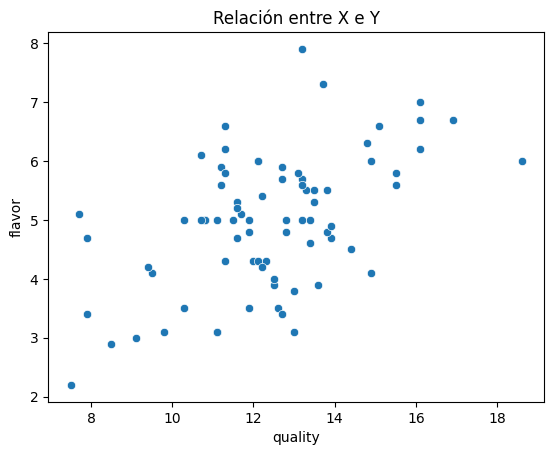

In [147]:
sns.scatterplot(x="quality", y="flavor", data=df)
plt.title("Relación entre X e Y")
plt.show()